# Model Exp

## setup

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

## models
import xgboost as xgb
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import average_precision_score
import lightgbm as lgb
from sklearn.linear_model import LogisticRegression


## load data

In [2]:
import sys
from pathlib import Path

# Add repo root to sys.path so `src` is importable from the notebooks/ dir
repo_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from src.data.load_data import load_data
from src.data.clean_data import clean_data
from src.data.preprocess import preprocess
from src.data.data_split import data_split
from src.features.features_engineer import features_engineer
from src.models.models import xgboost
from src.services.metrics import evaluate_model

/Users/thanakritp/Documents/Thanakrit_workspace/Class/practical-ml-final-project/Fraud-Detection/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# load data
df = load_data()

# clean data
df_clean = clean_data(df)

# preprocess data
df_prep = preprocess(df_clean)

# feature engineering
df_feat = features_engineer(df_prep)

# data split
X_train, X_test, y_train, y_test = data_split(df_feat)

In [4]:
X_train

,income,name_email_similarity,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,payment_type,zip_count_4w,velocity_6h,velocity_24h,...,has_other_cards,proposed_credit_limit,foreign_request,source,session_length_in_minutes,device_os,keep_alive_session,is_prev_address_months_count_available,is_bank_months_count_available,is_device_distinct_emails_8w_available
0,0.3,0.986506,3.258097,40,0.006713,4.778991,AA,6.966024,13096.035018,7850.955007,...,0,7.313887,0,INTERNET,2.846353,linux,1,0,1,1
1,0.8,0.617426,4.499810,20,0.010044,2.752450,AD,7.413970,9223.283431,5745.251481,...,0,7.313887,0,INTERNET,1.473356,other,1,0,1,1
2,0.8,0.996707,2.708050,40,0.012241,2.710725,AB,6.999422,4471.472149,5471.988958,...,0,5.303305,0,INTERNET,3.166764,windows,0,1,1,1
3,0.6,0.475100,2.708050,30,0.006967,2.685631,AB,8.155936,14431.993621,6755.344479,...,0,5.303305,0,INTERNET,2.785987,linux,1,1,1,1
4,0.9,0.842307,3.401197,40,1.908449,4.153918,AA,7.757906,7601.511579,5124.046930,...,0,5.303305,0,INTERNET,1.556680,other,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
794984,0.9,0.670058,4.615121,20,0.030853,2.787762,AB,7.891705,3445.858573,4733.316718,...,0,5.303305,0,INTERNET,0.109091,windows,0,0,1,1
794985,0.6,0.369424,2.772589,30,0.016682,2.798798,AD,6.690842,5361.336674,5022.548146,...,0,6.908755,0,INTERNET,2.245138,windows,1,1,1,1
794986,0.6,0.245233,3.713572,20,0.012243,2.761277,AB,7.061334,7011.340079,3736.164978,...,0,5.303305,0,INTERNET,0.437217,windows,0,0,1,1
794987,0.1,0.653664,2.302585,20,0.008469,2.777847,AC,7.996990,3347.956800,3570.438099,...,0,5.303305,0,INTERNET,1.881776,windows,0,0,0,1


In [5]:
# Identify categorical (string) columns once — used by every model below.
cat_cols = X_train.select_dtypes(include="object").columns.tolist()
num_cols = [c for c in X_train.columns if c not in cat_cols]
print("categorical:", cat_cols)

# Class imbalance ratio (neg / pos) for scale_pos_weight on the tree models.
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / pos
print(f"pos={pos}, neg={neg}, scale_pos_weight={scale_pos_weight:.1f}")

results = {}


categorical: ['payment_type', 'employment_status', 'housing_status', 'source', 'device_os']
pos=8151, neg=786838, scale_pos_weight=96.5


/var/folders/0w/dg96nhvx2qdd7h5pk8ft6mhh0000gn/T/ipykernel_77947/582839874.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include="object").columns.tolist()


## Models 

In [6]:
from sklearn.metrics import f1_score

cat_cols = X_train.select_dtypes(include="object").columns.tolist()
num_cols = [c for c in X_train.columns if c not in cat_cols]

results = {}

def best_f1_threshold(y_true, y_score):
    thresholds = np.linspace(0.01, 0.99, 99)
    f1s = [f1_score(y_true, (y_score >= t).astype(int), zero_division=0) for t in thresholds]
    best = int(np.argmax(f1s))
    return thresholds[best], f1s[best]

def score_model(name, train_score, test_score):
    t, _ = best_f1_threshold(y_train, train_score)
    y_pred = (test_score >= t).astype(int)
    results[name] = {**evaluate_model(y_test, y_pred, test_score), "threshold": t}
    return results[name]


/var/folders/0w/dg96nhvx2qdd7h5pk8ft6mhh0000gn/T/ipykernel_77947/3661465353.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include="object").columns.tolist()


In [32]:
def plot_feature_importance(model, feature_names, top_n=20, title=None):
    if hasattr(model, "feature_importances_"):      # LGBM / CatBoost / XGBoost
        importances = model.feature_importances_
    elif hasattr(model, "coef_"):                   # logistic regression
        importances = np.abs(model.coef_).ravel()
    else:
        raise ValueError("model exposes neither feature_importances_ nor coef_")

    order = np.argsort(importances)[::-1][:top_n]
    names = np.array(feature_names)[order]
    vals = importances[order]

    plt.figure(figsize=(8, max(4, 0.35 * len(order))))
    plt.barh(names[::-1], vals[::-1])               # largest at top
    plt.xlabel("importance")
    plt.title(title or type(model).__name__)
    plt.tight_layout()
    plt.show()


### Baseline model(logistic regression)

In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
])

logreg = Pipeline(steps=[
    ("prep", preprocessor),
    ("clf", LogisticRegression(max_iter=1000, n_jobs=-1)),
])
logreg.fit(X_train, y_train)

score_model("logistic_regression",
            logreg.predict_proba(X_train)[:, 1],
            logreg.predict_proba(X_test)[:, 1])


/Users/thanakritp/Documents/Thanakrit_workspace/Class/practical-ml-final-project/Fraud-Detection/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


{'precision': 0.23841059602649006,
 'recall': 0.2126476719944406,
 'f1_score': 0.22479338842975208,
 'pr_auc': 0.16003868604391647,
 'threshold': np.float64(0.09999999999999999)}

In [9]:
print("train pr_auc:", average_precision_score(y_train, logreg.predict_proba(X_train)[:, 1]))
print("test  pr_auc:", average_precision_score(y_test,  logreg.predict_proba(X_test)[:, 1]))

train pr_auc: 0.12630698748425173
test  pr_auc: 0.16003868604391647


## lightgbm without tuning

I add early stopping bc first try it's overfitting

In [ ]:
X_train_lgb, X_test_lgb = X_train.copy(), X_test.copy()
for c in cat_cols:
    X_train_lgb[c] = X_train_lgb[c].astype("category")
    X_test_lgb[c] = X_test_lgb[c].astype("category")

lgbm = LGBMClassifier(n_estimators=500, learning_rate=0.05, num_leaves=32,
                      n_jobs=-1, random_state=42)
lgbm.fit(
    X_train_lgb, y_train,
    eval_set=[(X_test_lgb, y_test)],          
    eval_metric="average_precision",
    categorical_feature=cat_cols,
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)],
)

score_model("lightgbm",
            lgbm.predict_proba(X_train_lgb)[:, 1],
            lgbm.predict_proba(X_test_lgb)[:, 1])


[LightGBM] [Info] Number of positive: 8151, number of negative: 786838
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018238 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2921
[LightGBM] [Info] Number of data points in the train set: 794989, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.010253 -> initscore=-4.569882
[LightGBM] [Info] Start training from score -4.569882
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[129]	valid_0's average_precision: 0.186661	valid_0's binary_logloss: 0.0550009


{'precision': 0.23081009296148738,
 'recall': 0.3019457956914524,
 'f1_score': 0.26162878217672736,
 'pr_auc': 0.18666114212301957,
 'threshold': np.float64(0.11)}

In [17]:
print("train pr_auc:", average_precision_score(y_train, lgbm.predict_proba(X_train_lgb)[:, 1]))
print("test  pr_auc:", average_precision_score(y_test,  lgbm.predict_proba(X_test_lgb)[:, 1]))

train pr_auc: 0.3138397829629379
test  pr_auc: 0.17625045052168054


## Catboost without tuning

In [19]:


catboost = CatBoostClassifier(iterations=500, learning_rate=0.02, depth=8,
                              random_seed=42, verbose=0)
catboost.fit(X_train, y_train, cat_features=cat_cols, early_stopping_rounds=50, eval_set=(X_test, y_test))

score_model("catboost",
            catboost.predict_proba(X_train)[:, 1],
            catboost.predict_proba(X_test)[:, 1])


{'precision': 0.2661570535093815,
 'recall': 0.2661570535093815,
 'f1_score': 0.2661570535093815,
 'pr_auc': 0.1912542078893003,
 'threshold': np.float64(0.12)}

In [20]:
print("train pr_auc:", average_precision_score(y_train, catboost.predict_proba(X_train)[:, 1]))
print("test  pr_auc:", average_precision_score(y_test,  catboost.predict_proba(X_test)[:, 1]))

train pr_auc: 0.22933239951540346
test  pr_auc: 0.1912542078893003


## Xgboost without tuning


In [40]:
from xgboost import XGBClassifier

X_train_xgb, X_test_xgb = X_train.copy(), X_test.copy()
for c in cat_cols:
    X_train_xgb[c] = X_train_xgb[c].astype("category")
    X_test_xgb[c] = X_test_xgb[c].astype("category")

xgb_model = XGBClassifier(
    n_estimators=500, learning_rate=0.02, max_depth=6,
    scale_pos_weight=scale_pos_weight,
    tree_method="hist", enable_categorical=True,   
    eval_metric="aucpr",                            
    early_stopping_rounds=50,                       
    n_jobs=-1, random_state=42,
)
xgb_model.fit(X_train_xgb, y_train, eval_set=[(X_test_xgb, y_test)], verbose=False)

score_model("xgboost",
            xgb_model.predict_proba(X_train_xgb)[:, 1],
            xgb_model.predict_proba(X_test_xgb)[:, 1])


{'precision': 0.2388772767990445,
 'recall': 0.27797081306462823,
 'f1_score': 0.25694555965954713,
 'pr_auc': 0.1873230462628581,
 'threshold': np.float64(0.9)}

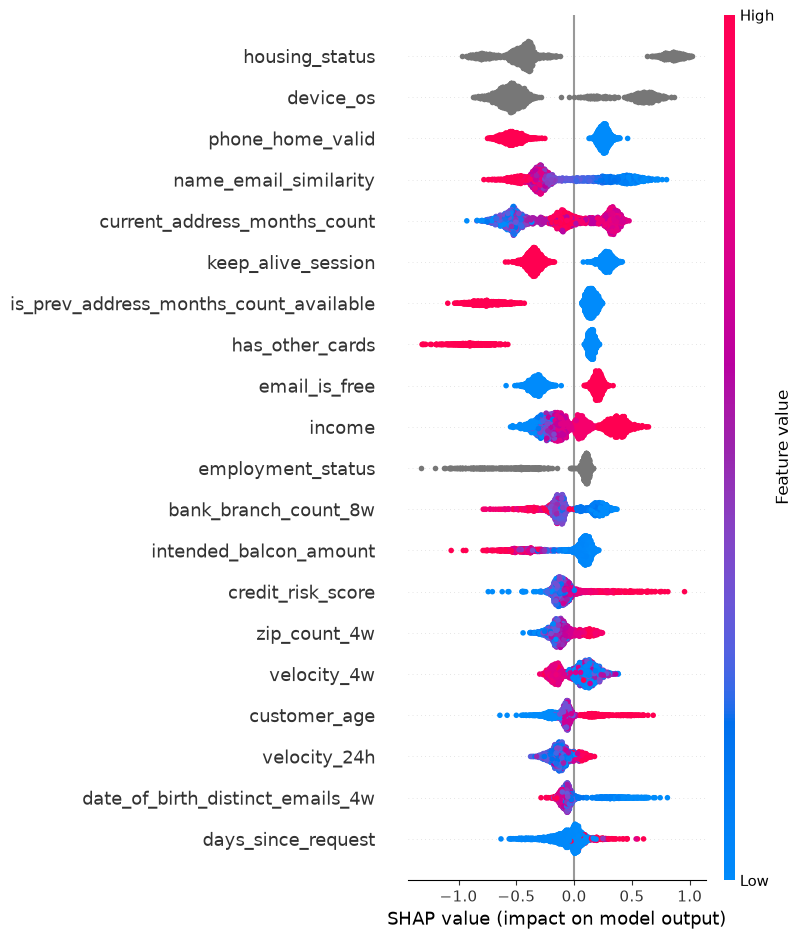

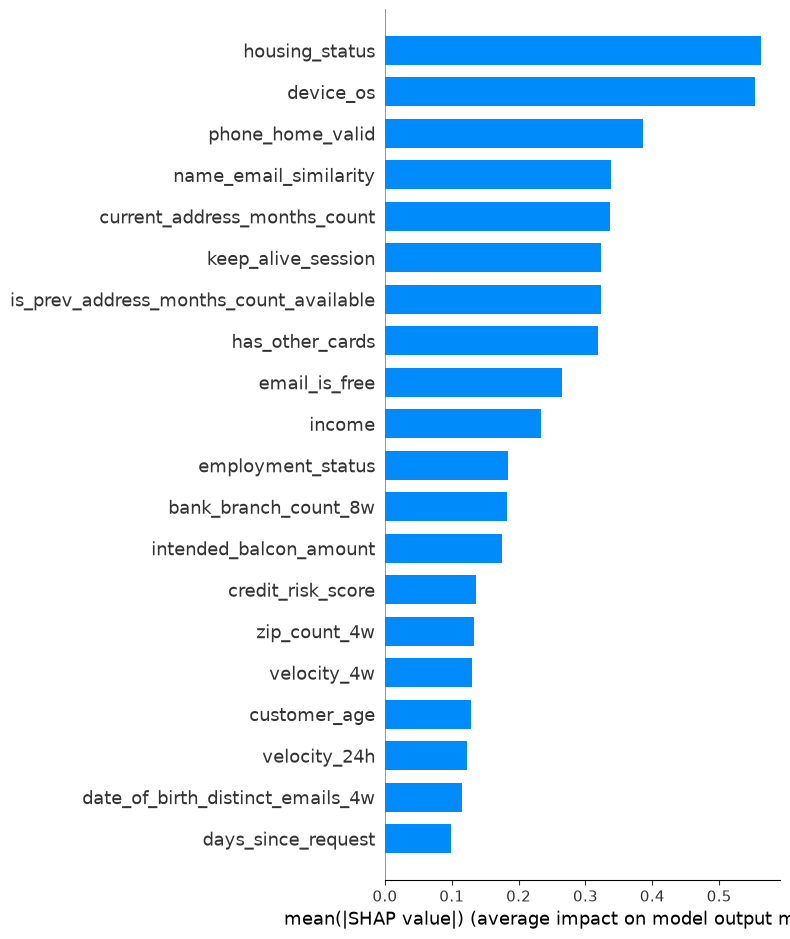

In [36]:
import shap

explainer = shap.TreeExplainer(xgb_model)          # or catboost / xgb_model

X_sample = X_test_lgb.sample(2000, random_state=42)   # use the category-dtype frame
shap_values = explainer.shap_values(X_sample)

shap.summary_plot(shap_values, X_sample)       # beeswarm: importance + direction
shap.summary_plot(shap_values, X_sample, plot_type="bar")   # global ranking


/Users/thanakritp/Documents/Thanakrit_workspace/Class/practical-ml-final-project/Fraud-Detection/.venv/lib/python3.11/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


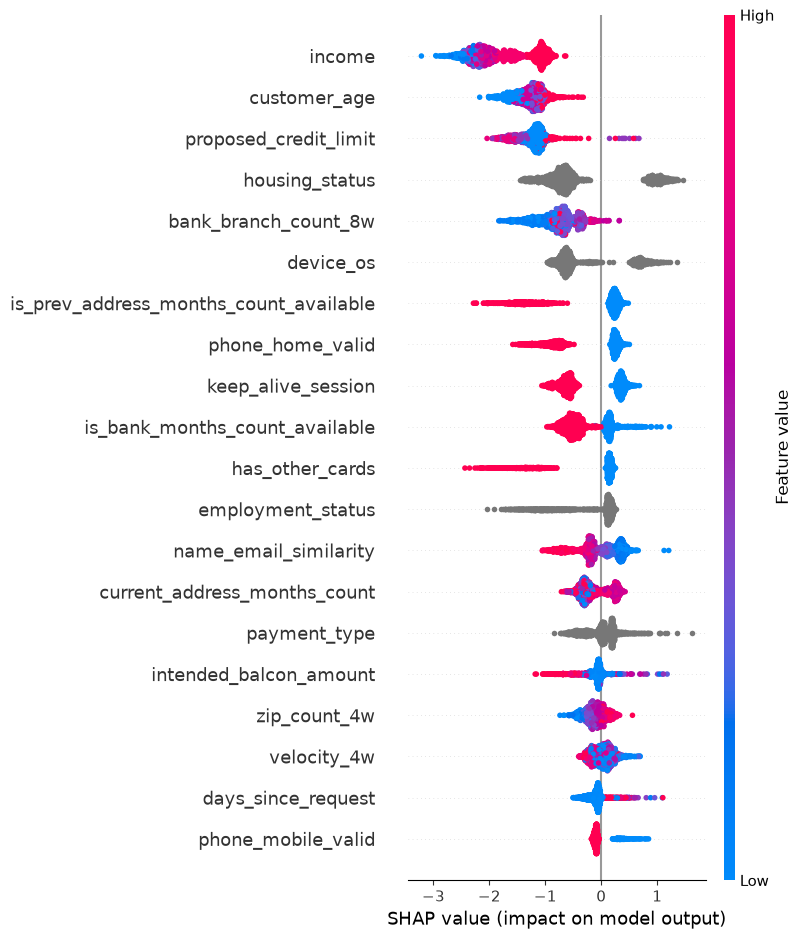

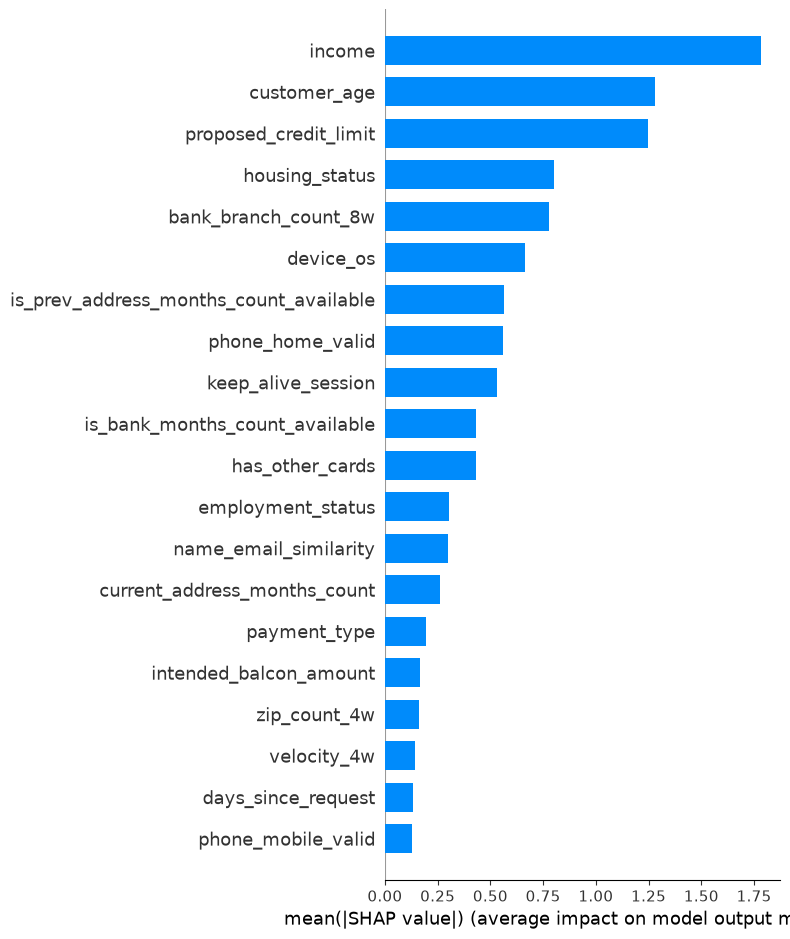

In [37]:
explainer = shap.TreeExplainer(lgbm)          # or catboost / xgb_model

X_sample = X_test_lgb.sample(2000, random_state=42)   # use the category-dtype frame
shap_values = explainer.shap_values(X_sample)

shap.summary_plot(shap_values, X_sample)       # beeswarm: importance + direction
shap.summary_plot(shap_values, X_sample, plot_type="bar")   # global ranking


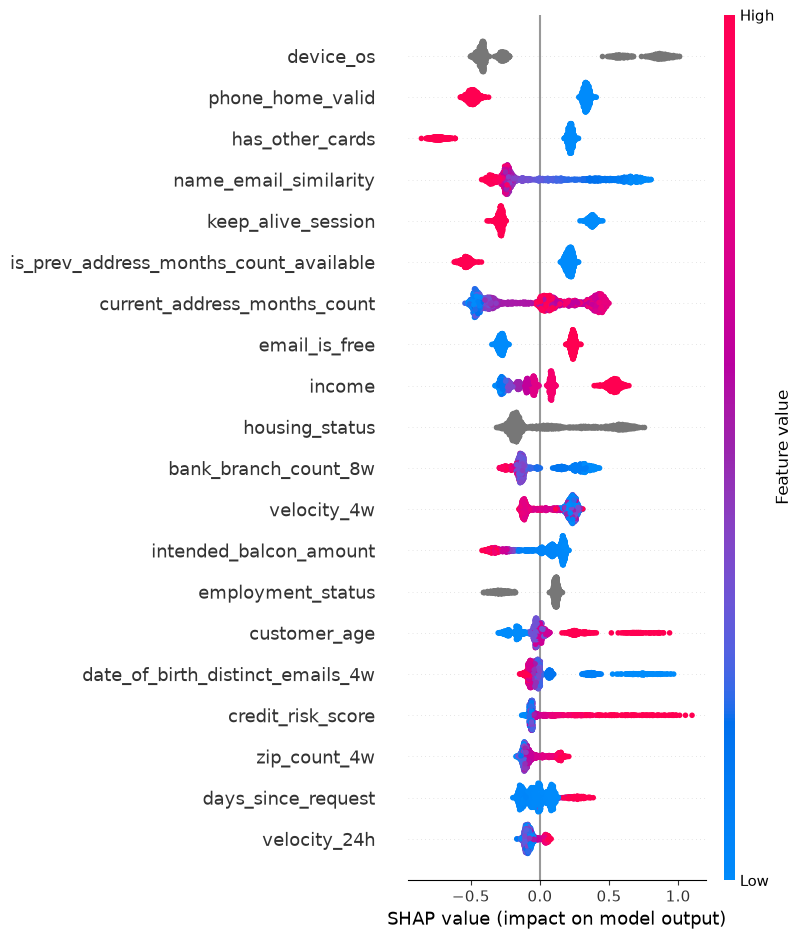

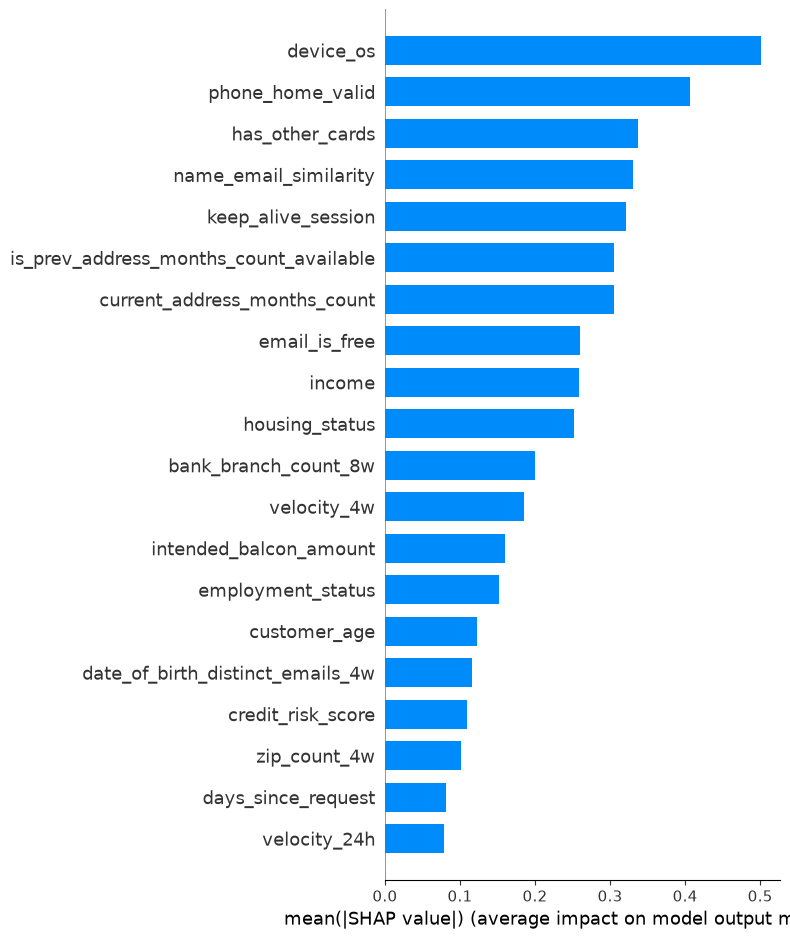

In [38]:
explainer = shap.TreeExplainer(catboost)          # or catboost / xgb_model

X_sample = X_test_lgb.sample(2000, random_state=42)   # use the category-dtype frame
shap_values = explainer.shap_values(X_sample)

shap.summary_plot(shap_values, X_sample)       # beeswarm: importance + direction
shap.summary_plot(shap_values, X_sample, plot_type="bar")   # global ranking


## SMOTE applied test


In [28]:
from imblearn.over_sampling import SMOTENC

# SMOTENC needs the categorical columns by position.
cat_idx = [X_train.columns.get_loc(c) for c in cat_cols]

smote = SMOTENC(categorical_features=cat_idx, random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("before:", y_train.value_counts().to_dict())
print("after :", y_train_res.value_counts().to_dict())   # now ~50/50


before: {0: 786838, 1: 8151}
after : {0: 786838, 1: 786838}


In [30]:
def to_cat(df):
    df = df.copy()
    for c in cat_cols:
        df[c] = df[c].astype("category")
    return df

In [29]:
logreg = Pipeline(steps=[
    ("prep", ColumnTransformer(transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ])),
    ("clf", LogisticRegression(max_iter=1000)),
])
logreg.fit(X_train_res, y_train_res)

score_model("logistic_regression_smote",
            logreg.predict_proba(X_train)[:, 1],  
            logreg.predict_proba(X_test)[:, 1])


{'precision': 0.20211827007943514,
 'recall': 0.15913829047949965,
 'f1_score': 0.1780715396578538,
 'pr_auc': 0.1130848584844909,
 'threshold': np.float64(0.92)}

In [31]:
X_res_lgb, X_train_lgb, X_test_lgb = to_cat(X_train_res), to_cat(X_train), to_cat(X_test)

lgbm = LGBMClassifier(n_estimators=500, learning_rate=0.05, num_leaves=32,
                      n_jobs=-1, random_state=42)
lgbm.fit(
    X_res_lgb, y_train_res,
    eval_set=[(X_test_lgb, y_test)],
    eval_metric="average_precision",
    categorical_feature=cat_cols,
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)],
)

score_model("lightgbm_smote",
            lgbm.predict_proba(X_train_lgb)[:, 1],
            lgbm.predict_proba(X_test_lgb)[:, 1])


[LightGBM] [Info] Number of positive: 786838, number of negative: 786838
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.062119 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3473
[LightGBM] [Info] Number of data points in the train set: 1573676, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[500]	valid_0's average_precision: 0.141558	valid_0's binary_logloss: 0.0596531


{'precision': 0.1801040312093628,
 'recall': 0.28874218207088254,
 'f1_score': 0.2218366257341164,
 'pr_auc': 0.14155753028301457,
 'threshold': np.float64(0.18000000000000002)}